In [1]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Any, cast

import matplotlib.pyplot as plt
import numpy as np
from IPython import get_ipython
from IPython.display import display
from sklearn.datasets import load_digits
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.model_selection import train_test_split

from students.kudryavcev.lesson3 import Exercise, Layer, LinearLayer, Model


In [2]:
MODEL_PATH = Path(
    "students/kudryavcev/lesson3/models/auto/20260407_031446_auto_1L_256r_lr0.0702001_bs16_ep60_acc0.9806.npz"
)
RANDOM_STATE = 42


In [3]:
digits = load_digits()
X = digits.data.astype(np.float32)
y = digits.target.astype(np.int64)
output_dim = int(np.unique(y).size)

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)
_X_train, _X_val, _y_train, _y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_train_val,
)

print(f"Test size: {len(X_test)}")


Test size: 360


In [4]:
def build_model(
    hidden_layers: list[tuple[int, str]],
    *,
    input_dim: int,
    output_dim: int,
    seed: int,
) -> Model:
    rng = np.random.default_rng(seed)
    layers: list[Layer] = []
    current_dim = input_dim

    for units, activation in hidden_layers:
        layers.append(Exercise.create_linear_layer(current_dim, units, rng))
        if activation == "relu":
            layers.append(Exercise.create_relu_layer())
        elif activation == "sigmoid":
            layers.append(Exercise.create_sigmoid_layer())
        else:
            raise ValueError(f"Unsupported activation: {activation}")
        current_dim = units

    layers.append(Exercise.create_linear_layer(current_dim, output_dim, rng))
    return Exercise.create_model(*layers)


def predict_classes(model: Model, x: np.ndarray) -> np.ndarray:
    logits = model.forward(x)
    return np.argmax(logits, axis=1)


def load_model_bundle(filepath: Path, *, seed: int = 0) -> tuple[Model, dict[str, Any]]:
    data = np.load(filepath, allow_pickle=False)
    arch_name = str(data["arch_name"])
    config_raw = cast(list[list[Any]], json.loads(str(data["config"])))
    config = [(int(units), str(activation)) for units, activation in config_raw]
    mean_vector = data["mean"].astype(np.float32)
    std_vector = data["std"].astype(np.float32)

    model = build_model(
        config,
        input_dim=int(mean_vector.shape[0]),
        output_dim=output_dim,
        seed=seed,
    )

    linear_idx = 0
    for layer in model.layers:
        if isinstance(layer, LinearLayer):
            layer.weights = data[f"weight_{linear_idx}"].astype(np.float32)
            layer.bias = data[f"bias_{linear_idx}"].astype(np.float32)
            linear_idx += 1

    metadata: dict[str, Any] = {
        "arch_name": arch_name,
        "config": config,
        "mean": mean_vector,
        "std": std_vector,
    }
    return model, metadata


def plot_confusion(y_true: np.ndarray, y_pred: np.ndarray, *, title: str) -> None:
    fig, ax = plt.subplots(figsize=(7, 7))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, ax=ax, cmap="Blues")
    ax.set_title(title)
    plt.tight_layout()
    if get_ipython() is not None:
        display(fig)
    plt.close(fig)


Model path: students/kudryavcev/lesson3/models/auto/20260407_031446_auto_1L_256r_lr0.0702001_bs16_ep60_acc0.9806.npz
Architecture: 1L_256r
Config: [(256, 'relu')]
Test accuracy: 0.9806


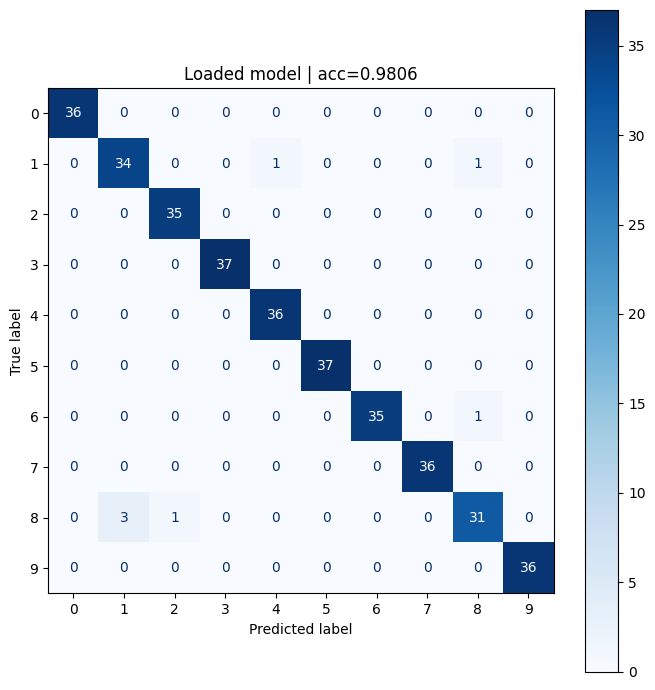

In [5]:
model, metadata = load_model_bundle(MODEL_PATH, seed=2026)
mean = cast(np.ndarray, metadata["mean"])
std = cast(np.ndarray, metadata["std"])
config = cast(list[tuple[int, str]], metadata["config"])
arch_name = str(metadata["arch_name"])

X_test_norm = (X_test - mean) / std
y_pred = predict_classes(model, X_test_norm)
test_accuracy = float(accuracy_score(y_test, y_pred))

print(f"Model path: {MODEL_PATH}")
print(f"Architecture: {arch_name}")
print(f"Config: {config}")
print(f"Test accuracy: {test_accuracy:.4f}")

plot_confusion(
    y_test,
    y_pred,
    title=f"Loaded model | acc={test_accuracy:.4f}",
)
